In [1]:
using JLD
using CairoMakie

In [2]:
struct Data
    L::Int
    t::Vector{Float64}
    x::Vector{Float64}
end

In [3]:
set_theme!(
    fontsize=28,
    Legend=(labelsize=28,),
    Axis=(
        xgridvisible=false,
        ygridvisible=false,
    )
)

In [4]:
# ==========================================
# Load data for fidelity correlator
# ==========================================

L_list = 6:12

data = Data[]
for L in L_list
    d = load("Ising//random_initial_state//averaged_Fidelity_J=1.0_h=0.0_L=$(L).jld")
    t = d["t"]
    x = d["F"]
    push!(data, Data(L, t, x))
end

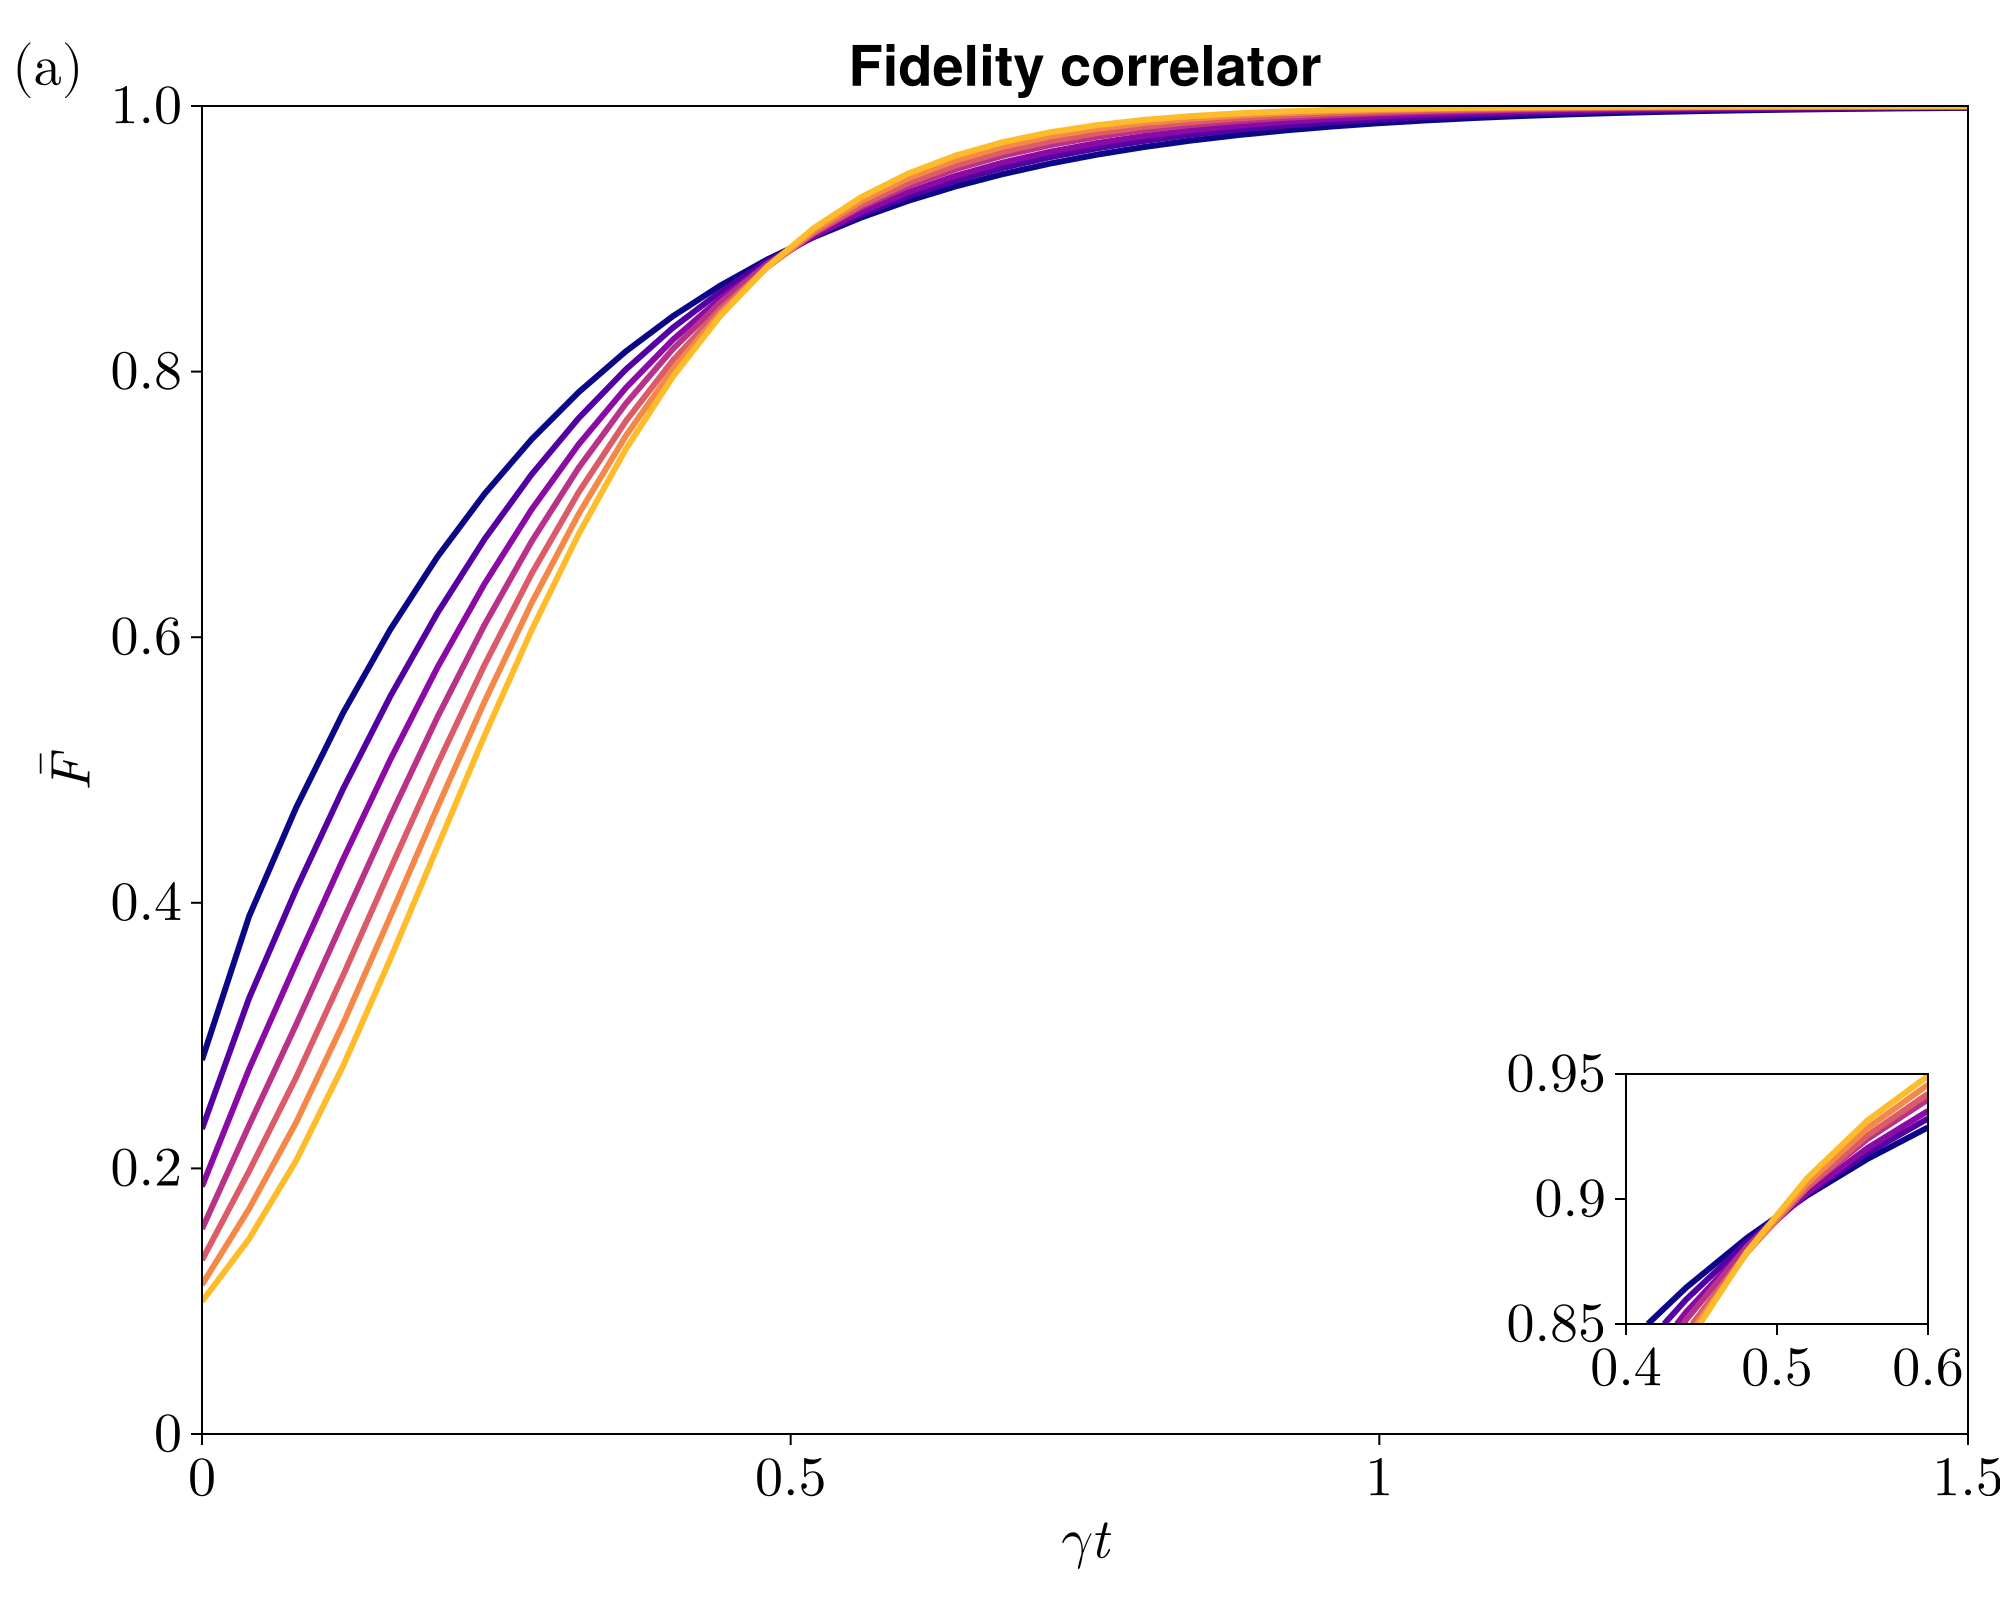

In [5]:
# ==========================================
# Plot raw data for fidelity correlator
# ==========================================

fig = Figure(size=(1000, 800))

ax = Axis(fig[1, 1];
    xticks=(0:0.5:2, [L"0", L"0.5", L"1", L"1.5", L"2"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\bar{F}",
    title="Fidelity correlator")

xlims!(ax, 0, 1.5)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / (length(data))] for i in 1:length(data)]

label_list = [L"L = 6", L"L = 7", L"L = 8", L"L = 9", L"L = 10", L"L = 11", L"L = 12"]

for (i, d) in enumerate(data)
    lines!(ax, d.t, d.x, label=label_list[i], linewidth=3, color = color_val[i])
end

# --- Inset ---
sub_gl = GridLayout(fig[1, 1], 
    tellwidth = false, 
    tellheight = false, 
    halign = :right, 
    valign = :bottom,
    width = 250,
    height = 200
)

ax_inset = Axis(sub_gl[1, 1],
    xticks=(0.4:0.1:0.6, [L"0.4", L"0.5", L"0.6"]),
    yticks=(0.85:0.05:0.95, [L"0.85", L"0.9", L"0.95"]),
    backgroundcolor = :white
)

xlims!(ax_inset, 0.4, 0.6)
ylims!(ax_inset, 0.85, 0.95)

for (i, d) in enumerate(data)
    lines!(ax_inset, d.t, d.x, label=label_list[i], linewidth=3, color = color_val[i])
end

sub_gl.alignmode = Outside(20)

Label(fig[1, 1, TopLeft()], L"\mathrm{(a)}";
    fontsize=28,
    halign=:left,
    padding=(-10, 0, 0, 0))

fig

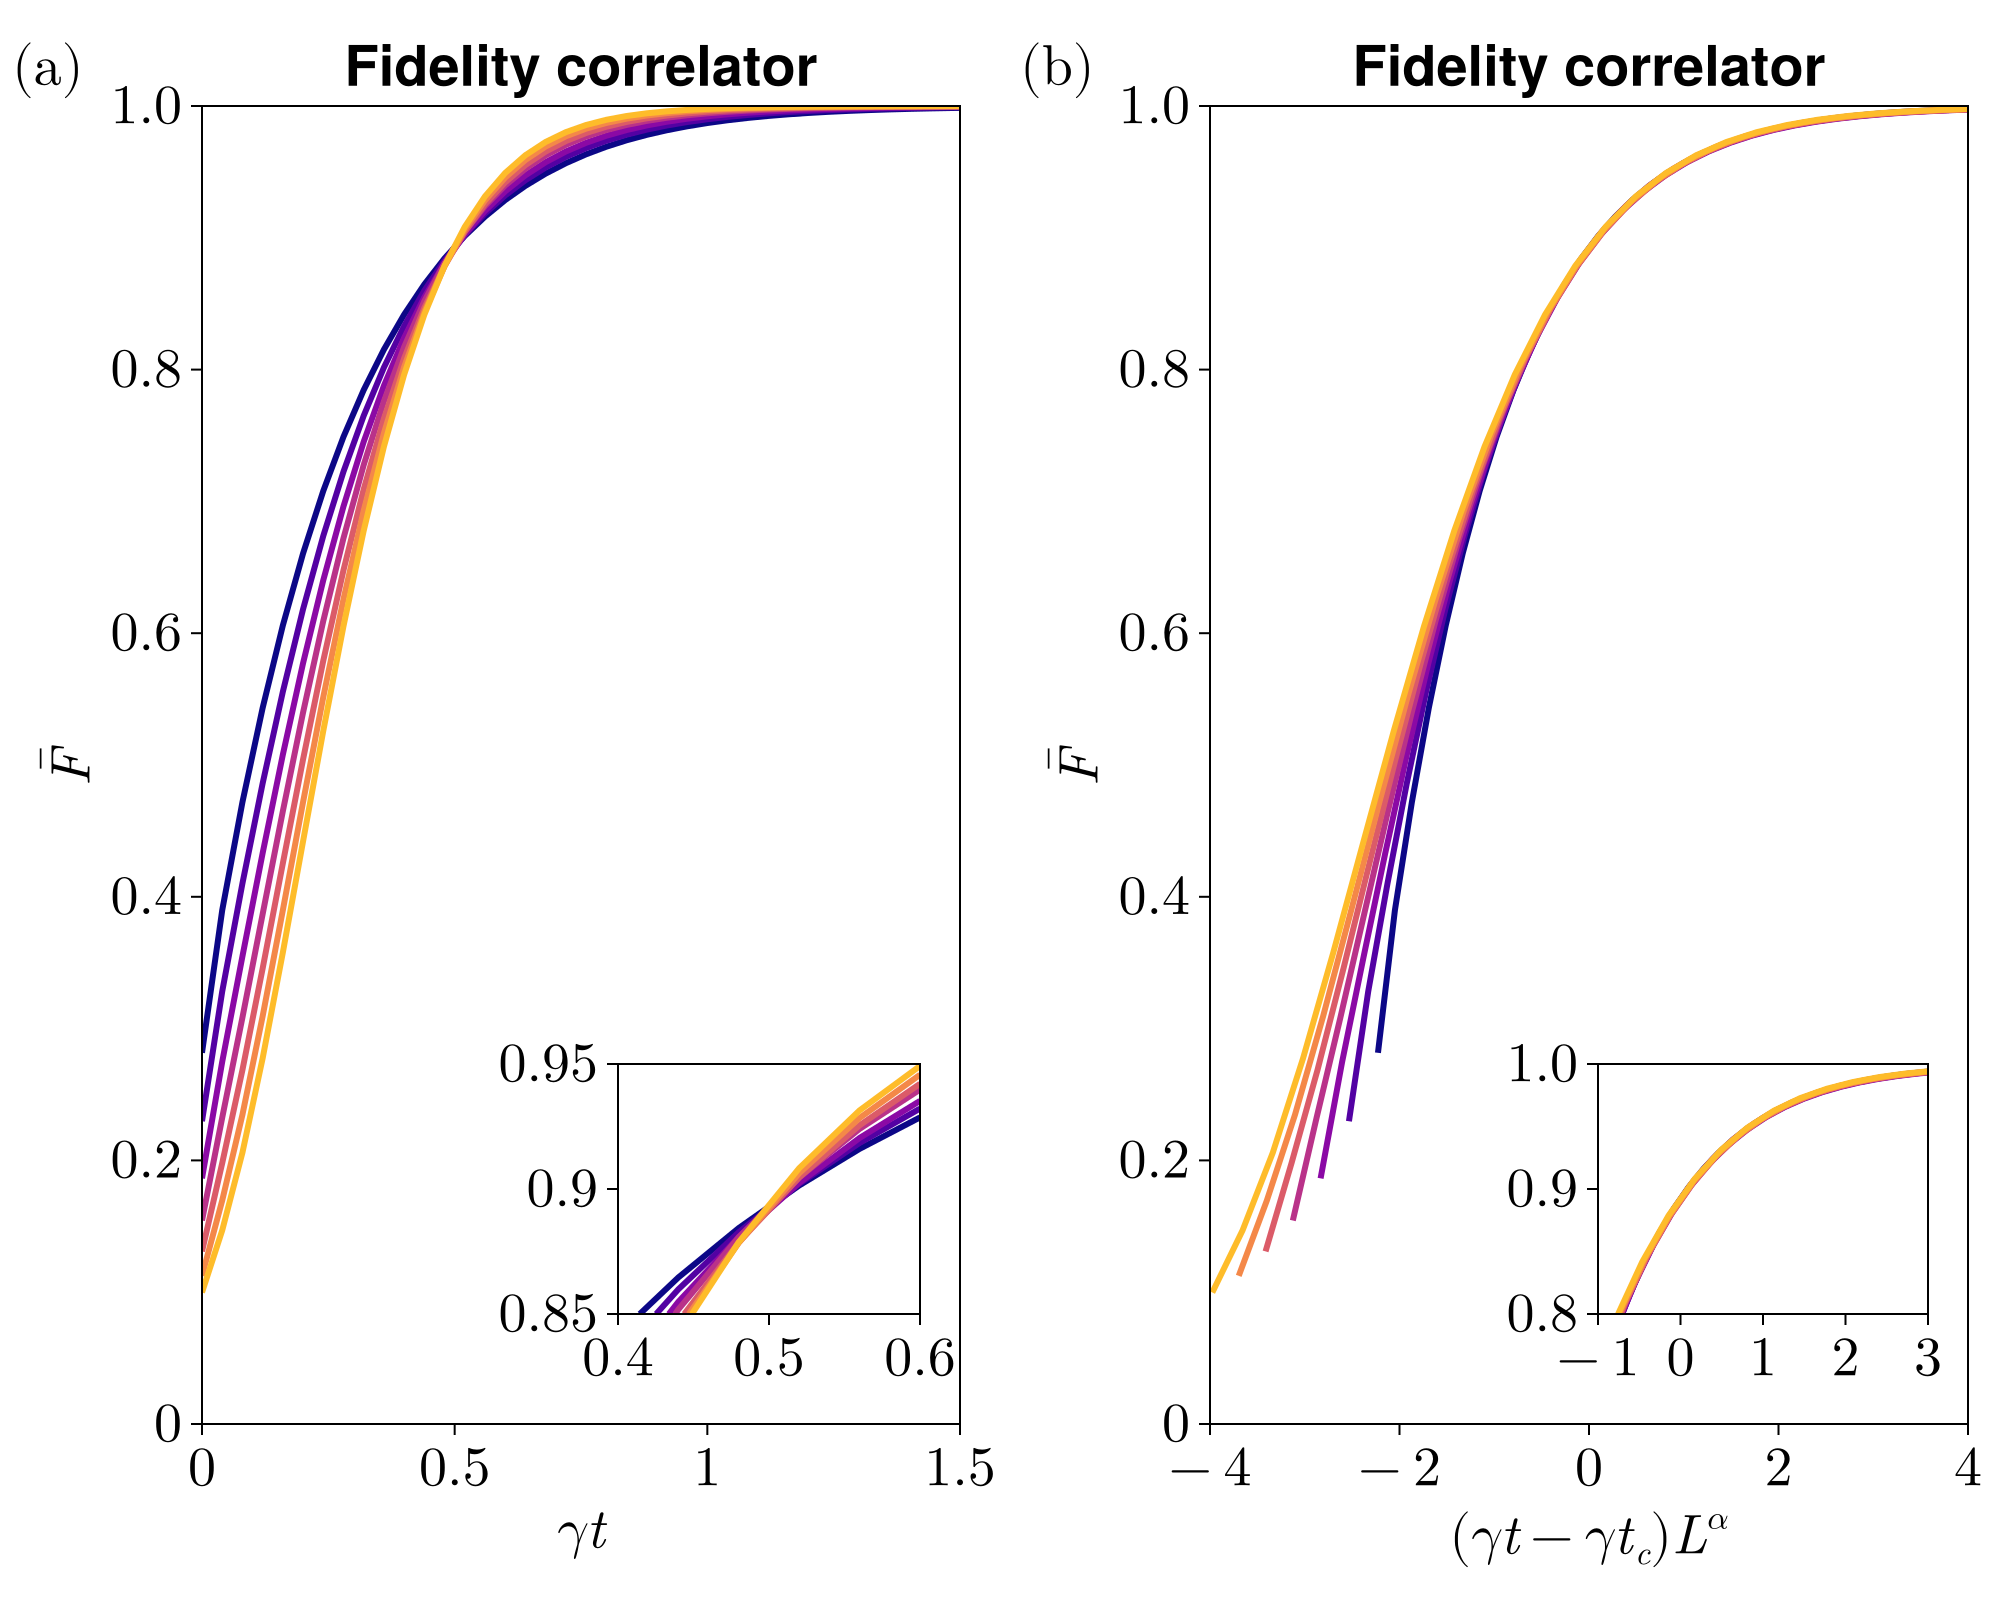

In [6]:
# ==========================================
# Finite-size scaling for fidelity correlator
# ==========================================

tc    = 0.4981
alpha = 0.8359

ax = Axis(fig[1, 2];
    xticks=(-4:2:4, [L"-4", L"-2", L"0", L"2", L"4"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"(\gamma t - \gamma t_c) L^\alpha",
    ylabel=L"\bar{F}",
    title="Fidelity correlator")

xlims!(ax, -4, 4)
ylims!(ax, 0, 1)

for (i, d) in enumerate(data)
    lines!(ax, (d.t .- tc) * d.L ^ alpha, d.x, label=label_list[i], linewidth=3, color = color_val[i])
end

# --- Inset ---
sub_gl = GridLayout(fig[1, 2], 
    tellwidth = false, 
    tellheight = false, 
    halign = :right, 
    valign = :bottom,
    width = 250,
    height = 200
)

ax_inset = Axis(sub_gl[1, 1],
    xticks=(-1:3, [L"-1", L"0", L"1", L"2", L"3"]),
    yticks=(0.8:0.1:1.0, [L"0.8", L"0.9", L"1.0"]),
    backgroundcolor = :white
)

xlims!(ax_inset, -1.0, 3.0)
ylims!(ax_inset, 0.8, 1.0)

for (i, d) in enumerate(data)
    lines!(ax_inset, (d.t .- tc) * d.L ^ alpha, d.x, label=label_list[i], linewidth=3, color = color_val[i])
end

sub_gl.alignmode = Outside(20)

Label(fig[1, 2, TopLeft()], L"\mathrm{(b)}";
    fontsize=28,
    halign=:left,
    padding  = (-10, 0, 0, 0))

colgap!(fig.layout, 1, Relative(0.05))

fig

In [7]:
# ==========================================
# Load data for Renyi-2 correlator
# ==========================================

L_list = 6:12

data = Data[]
for L in L_list
    d = load("Ising//random_initial_state//averaged_R2_J=1.0_h=0.0_L=$(L).jld")
    t = d["t"]
    x = d["R2"]
    push!(data, Data(L, t, x))
end

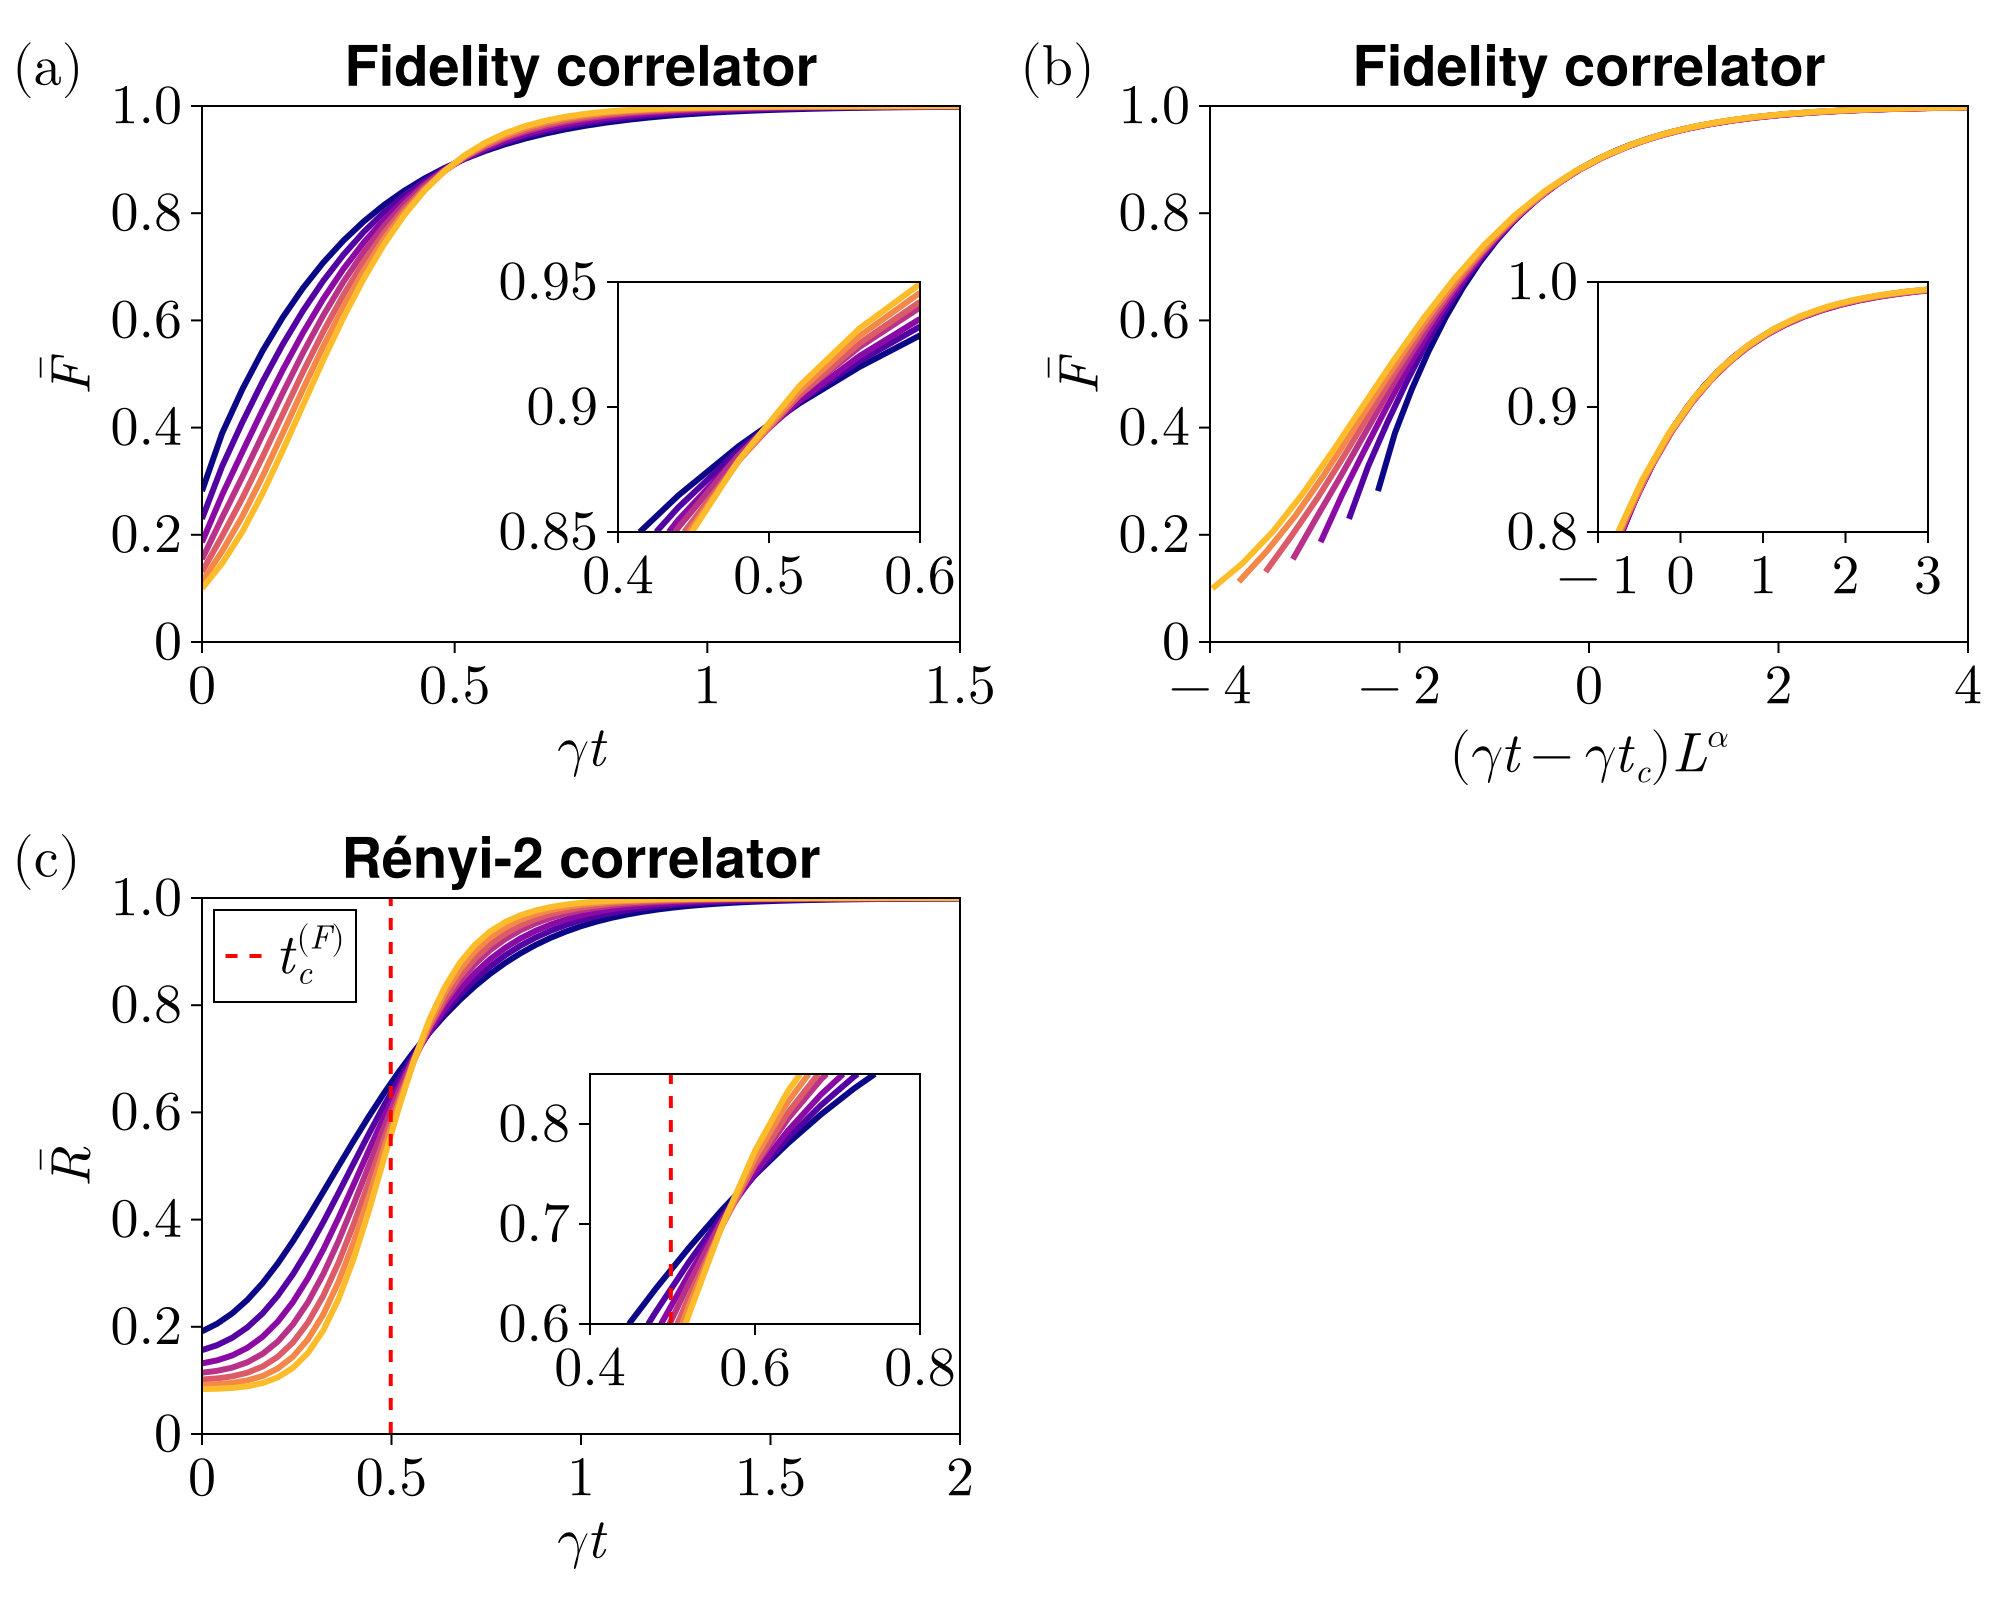

In [8]:
# ==========================================
# Plot raw for Renyi-2 correlator
# ==========================================

ax = Axis(fig[2, 1];
    xticks=(0:0.5:2, [L"0", L"0.5", L"1", L"1.5", L"2"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"\gamma t",
    ylabel=L"\bar{R}",
    title="Rényi-2 correlator")

xlims!(ax, 0, 2)
ylims!(ax, 0, 1)

cmap = cgrad(:plasma)
color_val = [cmap[(i - 1) / (length(data))] for i in 1:length(data)]

label_list = [L"L = 6", L"L = 7", L"L = 8", L"L = 9", L"L = 10", L"L = 11", L"L = 12"]

for (i, d) in enumerate(data)
    lines!(ax, d.t, d.x, linewidth=3, color = color_val[i])
end

vlines!(ax, [0.498], linestyle = :dash, linewidth = 2, color = :red,
    label=L"t_c^{(F)}")

axislegend(ax; position=:lt)

# --- Inset ---
sub_gl = GridLayout(fig[2, 1], 
    tellwidth = false, 
    tellheight = false, 
    halign = :right, 
    valign = :bottom,
    width = 250,
    height = 200
)

ax_inset = Axis(sub_gl[1, 1],
    xticks=(0.4:0.2:0.8, [L"0.4", L"0.6", L"0.8"]),
    yticks=(0.6:0.1:0.8, [L"0.6", L"0.7", L"0.8"]),
    backgroundcolor = :white
)

xlims!(ax_inset, 0.4, 0.8)
ylims!(ax_inset, 0.6, 0.85)

for (i, d) in enumerate(data)
    lines!(ax_inset, d.t, d.x, linewidth=3, color = color_val[i])
end

vlines!(ax_inset, [0.498], linestyle = :dash, linewidth = 2, color = :red,
    label=L"t_c^{(F)}")

sub_gl.alignmode = Outside(20)

Label(fig[2, 1, TopLeft()], L"\mathrm{(c)}";
    fontsize=28,
    halign=:left,
    padding=(-10, 0, 0, 0))

fig

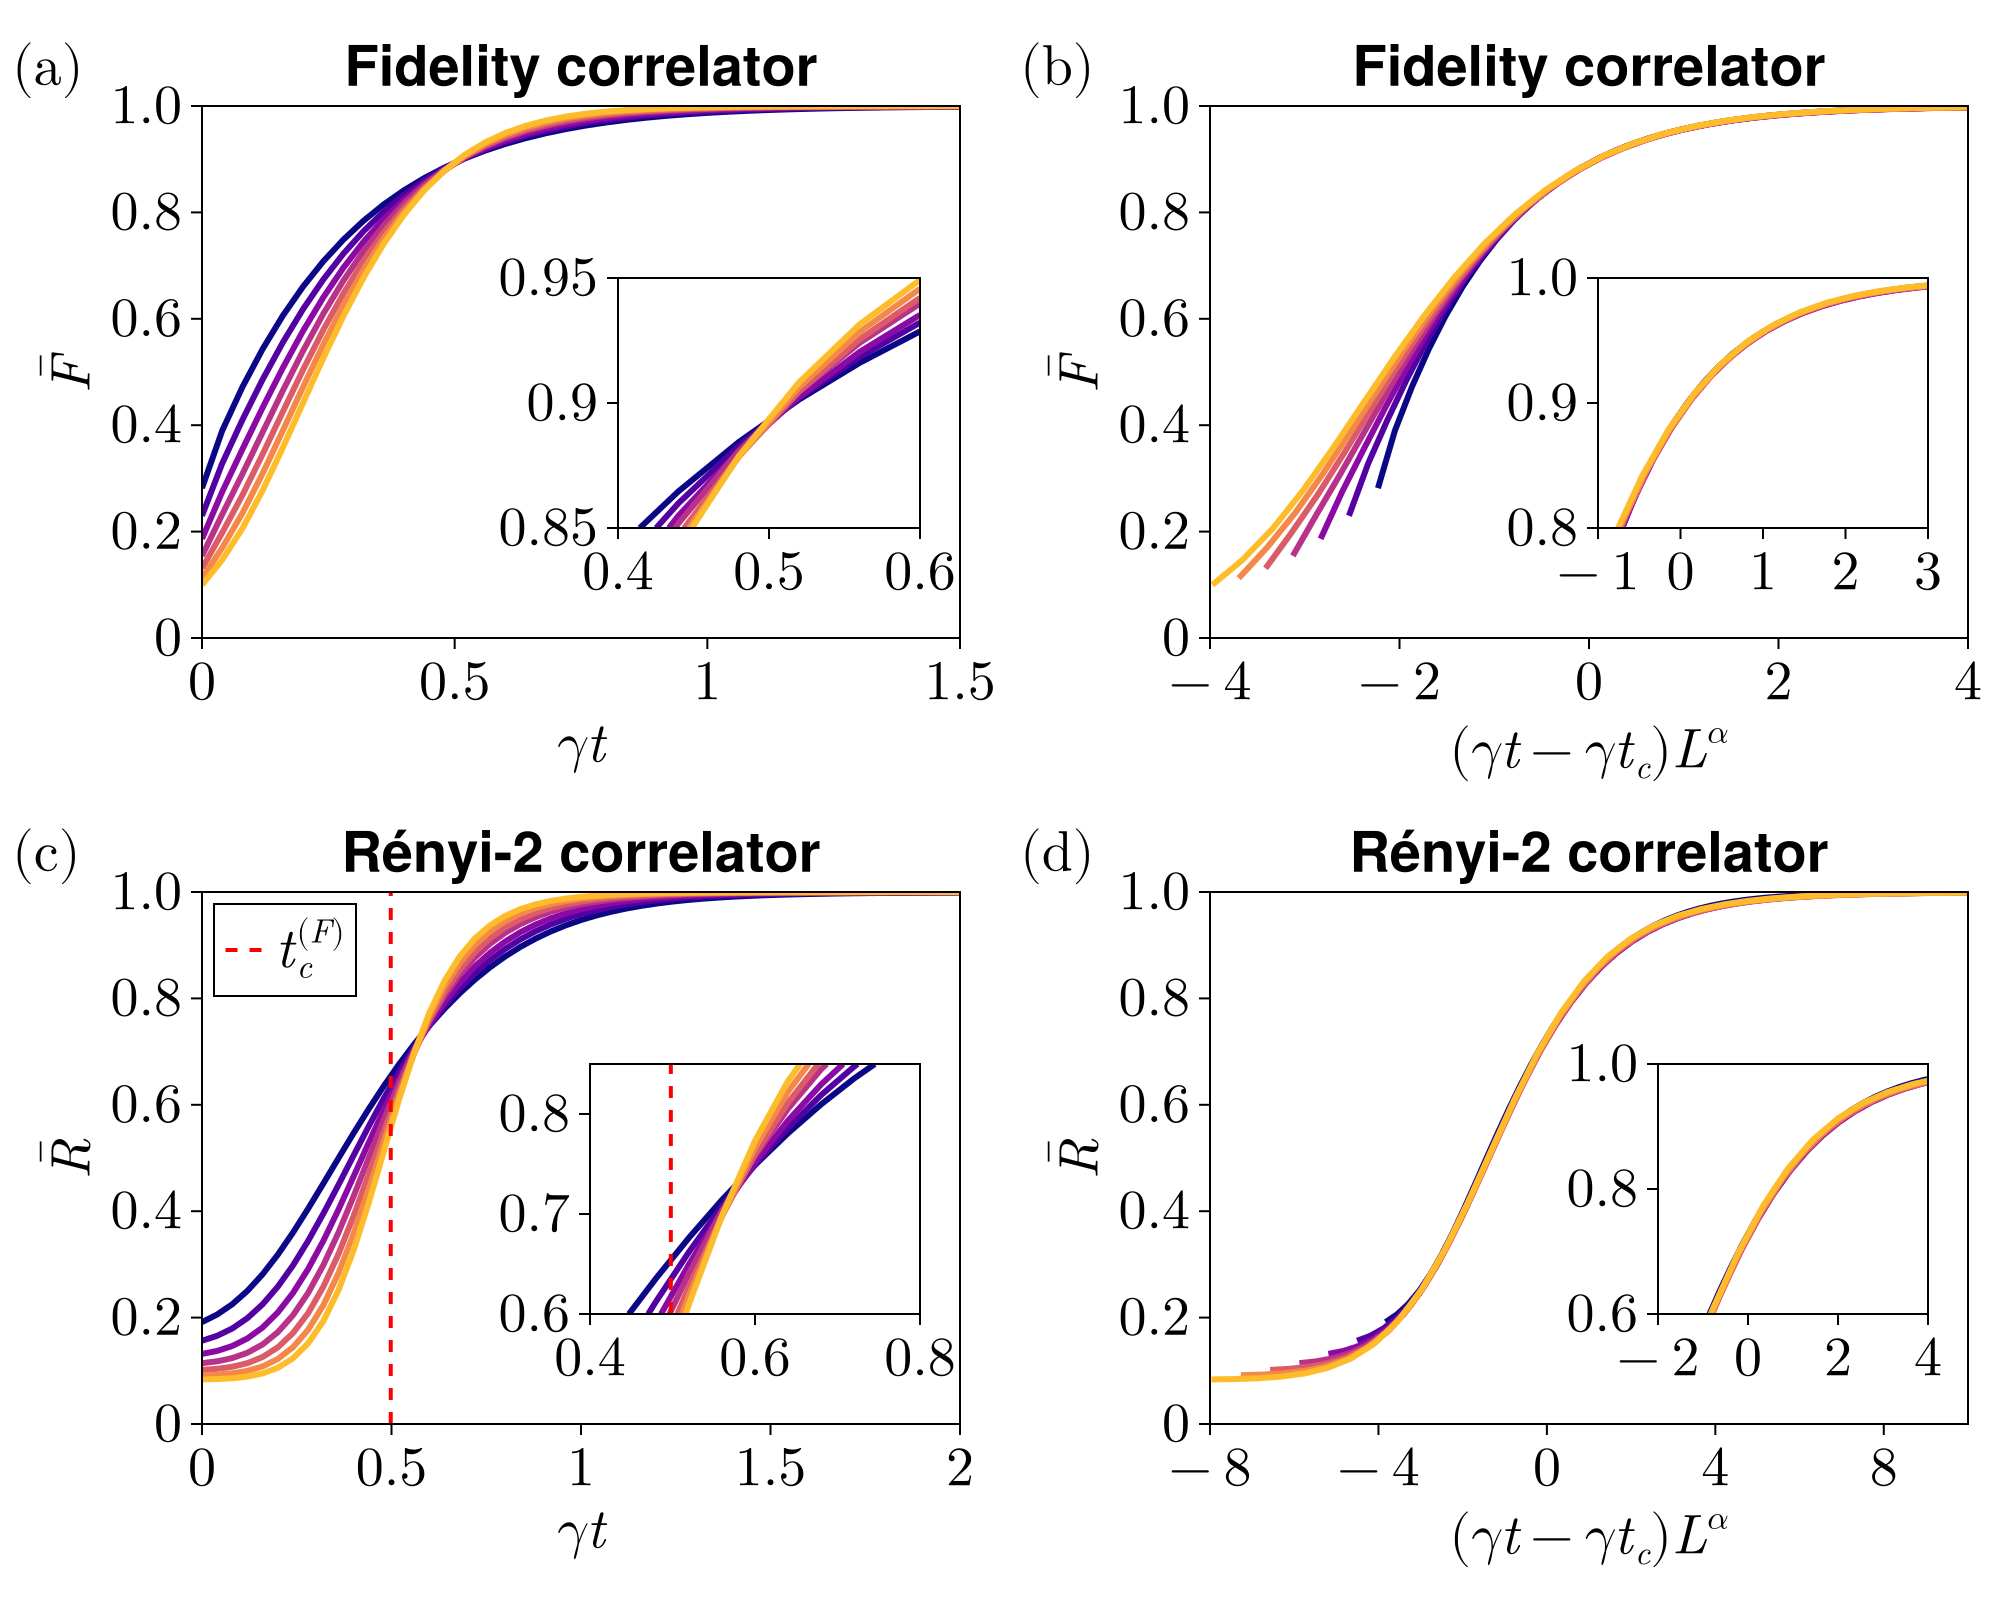

In [9]:
# ==========================================
# Finite-size scaling for Renyi-2 correlator
# ==========================================

tc    = 0.5757
alpha = 1.0574

ax = Axis(fig[2, 2];
    xticks=(-8:4:8, [L"-8", L"-4", L"0", L"4", L"8"]),
    yticks=(0:0.2:1.0, [L"0", L"0.2", L"0.4", L"0.6", L"0.8", L"1.0"]),
    xlabel=L"(\gamma t - \gamma t_c) L^\alpha",
    ylabel=L"\bar{R}",
    title="Rényi-2 correlator")

xlims!(ax, -8, 10)
ylims!(ax, 0, 1)

for (i, d) in enumerate(data)
    lines!(ax, (d.t .- tc) * d.L ^ alpha, d.x, linewidth=3, color = color_val[i])
end

# --- Insetの作成 ---
sub_gl = GridLayout(fig[2, 2], 
    tellwidth = false, 
    tellheight = false, 
    halign = :right, 
    valign = :bottom,
    width = 220,
    height = 200
)

ax_inset = Axis(sub_gl[1, 1],
    xticks=(-2:2:4, [L"-2", L"0", L"2", L"4"]),
    yticks=(0.6:0.2:1.0, [L"0.6", L"0.8", L"1.0"]),
    backgroundcolor = :white
)

xlims!(ax_inset, -2.0, 4.0)
ylims!(ax_inset, 0.6, 1.0)

for (i, d) in enumerate(data)
    lines!(ax_inset, (d.t .- tc) * d.L ^ alpha, d.x, linewidth=3, color = color_val[i])
end

sub_gl.alignmode = Outside(20)

Label(fig[2, 2, TopLeft()], L"\mathrm{(d)}";
    fontsize=28,
    halign=:left,
    padding  = (-10, 0, 0, 0))

colgap!(fig.layout, 1, Relative(0.05))

fig